In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats, mad_std, SigmaClip
from astropy.modeling import models, fitting
from astropy.nddata import CCDData, Cutout2D

from photutils.centroids import centroid_com, centroid_quadratic, centroid_2dg, centroid_1dg
from photutils.profiles import RadialProfile, CurveOfGrowth

from utils import (fit_moffat2d, fit_gaussian2d, fft_recenter, strehl_ratio, pupil2psf, savefits, crop_img, fit_gauss_moffat_1d, fft_oversample2d,
                    fit_gauss_airy_1d, fit_airy_moffat_1d, fit_moffat_airy_2d, fit_moffat_gauss_2d, fwhm_2d, radial_fwhm)

# Read file

In [2]:
ninox_path = '/home/tinmai/Desktop/AOC/base_folder_NINOXData/2025-07-17_NINOX/vega_20250717T215701418_SC_+H_0000s005_000002.fits' # short exposure

# Stacked image (no need for dark subtraction)
# ninox_path = '/home/tinmai/Desktop/AOC/stacked.fits'

with fits.open(ninox_path) as hdul:
    data = hdul[0].data

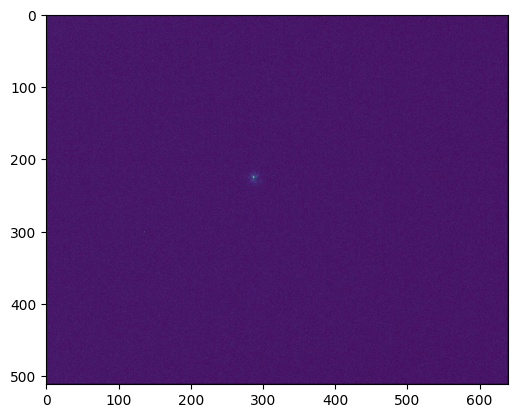

In [3]:
plt.imshow(data)

# Dark subtraction (Optional)

In [4]:
dark = CCDData.read('/home/tinmai/Desktop/AOC/combined_dark.fit', unit = 'adu').data

# dat = image.astype(np.float32)
dark  = dark.astype(np.float32)
# dark_masked = np.ma.masked_where(dark > 2000, dark)
# dark_nan = dark_masked.filled(np.nan)
# image = np.subtract(image, dark_masked)

data_dark_subtracted = data - dark

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


the DATE-REF keyword is non-standard. [astropy.wcs.wcs]


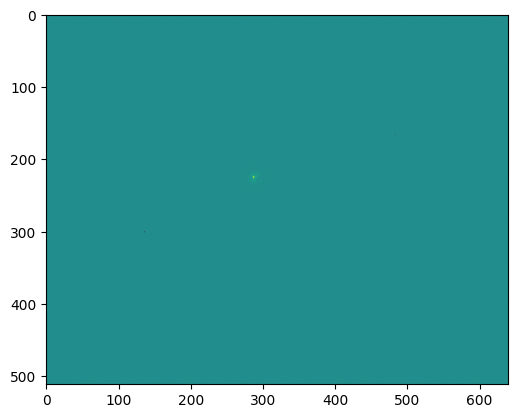

In [5]:
plt.imshow(data_dark_subtracted)

## Handling bad pixels

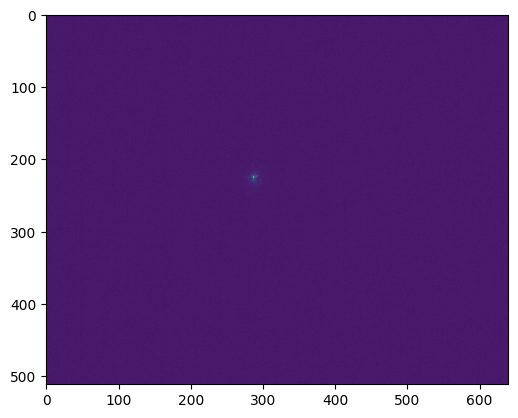

In [6]:
from astropy.convolution import Gaussian2DKernel
from astropy.convolution import interpolate_replace_nans

data_dark_subtracted[dark > 2000] = np.nan
result = interpolate_replace_nans(data_dark_subtracted, kernel = Gaussian2DKernel(1))

data = result

plt.imshow(data)

# Crop image

In [7]:
size = 256
img = crop_img(data, (size,size))

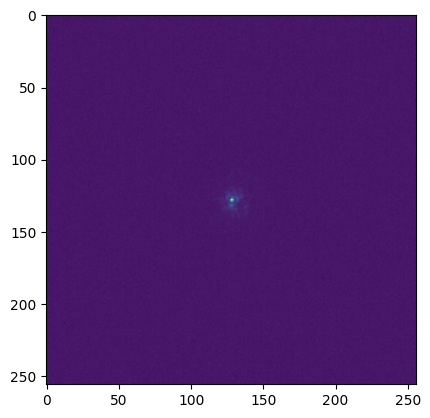

In [8]:
plt.imshow(img)

In [9]:
np.median(img)

-156.45638

# Background subtraction (Optional)

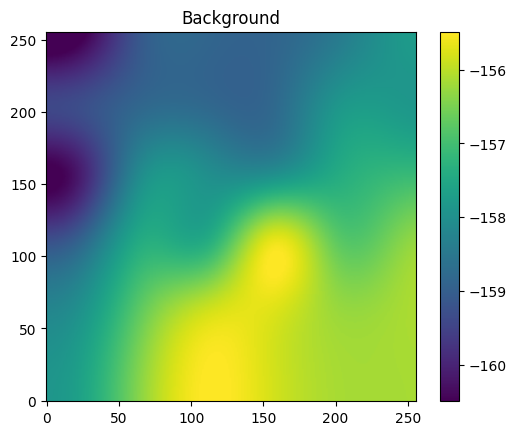

In [10]:
from photutils.background import Background2D, MedianBackground, MMMBackground, SExtractorBackground, BiweightLocationBackground

sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = SExtractorBackground()
bkg = Background2D(img, (45, 45), filter_size=(3, 3),
                   sigma_clip=sigma_clip)

plt.figure()
plt.title('Background')
plt.imshow(bkg.background, origin='lower')
plt.colorbar()

(100.0, 156.0)

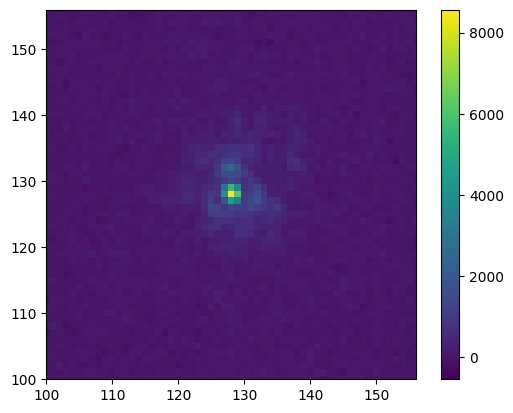

In [11]:
img = np.subtract(img, bkg.background, dtype = np.float32)

plt.figure()
plt.imshow(img, origin = 'lower')
plt.colorbar()
plt.xlim([100,156])
plt.ylim([100,156])

In [12]:
np.median(img)

1.1276093

# Oversampling

In [13]:
factor = 4
img_oversampled = fft_oversample2d(img, factor=factor)

(442.0, 582.0)

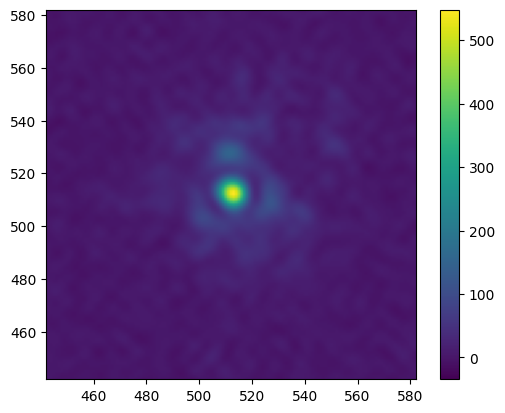

In [14]:
plt.figure()
plt.imshow(img_oversampled, origin = 'lower')
plt.colorbar()
plt.xlim([442,582])
plt.ylim([442,582])

In [15]:
print(img_oversampled[np.unravel_index(np.argmax(img_oversampled), img_oversampled.shape)])

548.5307075254328


# Recenter

549.7636137413773


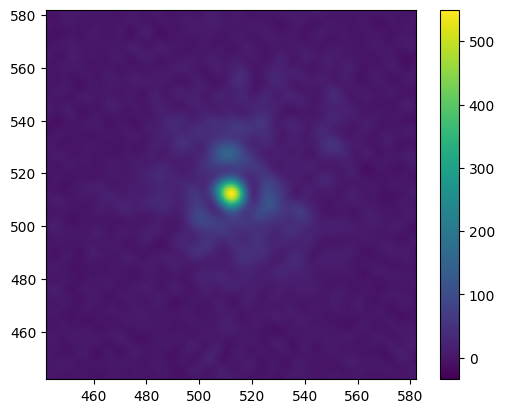

In [16]:
shifted_img = fft_recenter(img_oversampled)

plt.imshow(shifted_img, origin='lower')
plt.colorbar()
plt.xlim([442,582])
plt.ylim([442,582])

print(shifted_img[np.unravel_index(np.argmax(shifted_img), shifted_img.shape)])

In [17]:
img_oversampled = shifted_img

# Radial profile

## Centroid estimation

(442.0, 582.0)

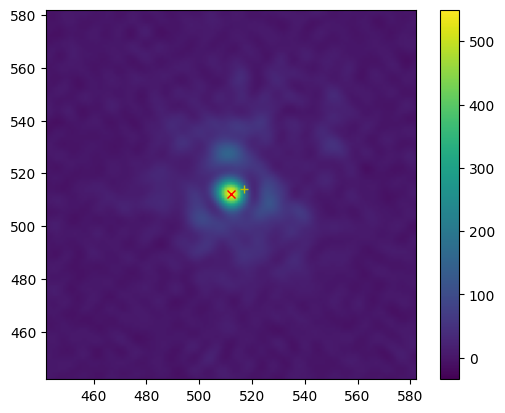

In [18]:
avg, med, std = sigma_clipped_stats(img_oversampled, stdfunc=mad_std)  # by default, 3-sigma 5-iteration.
thresh_3sig = med + 3 * std
mask_3sig = (img_oversampled < thresh_3sig)

center = centroid_quadratic(data=img_oversampled, mask=mask_3sig) # fitting a 2D quadratic polynomial
center_com = centroid_com(data=img_oversampled, mask=mask_3sig) # center of mass

# Uncomment to see the difference between with and without sigma clipping

# center = centroid_quadratic(data=img_oversampled) 
# center_com = centroid_com(data=img_oversampled)

plt.figure()
plt.plot(*center, 'rx')
plt.plot(*center_com, '+y')

plt.imshow(img_oversampled, origin = 'lower')
plt.colorbar()
plt.xlim([442,582])
plt.ylim([442,582])

In [19]:
center

array([512.10917875, 512.18563519])

## Radial profile

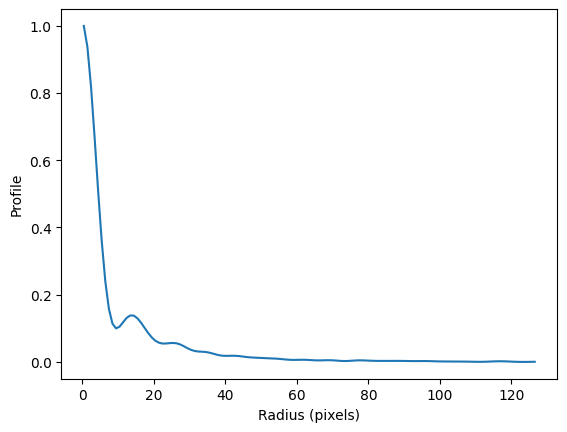

In [20]:
edge_radii = np.arange(128)
rp = RadialProfile(img_oversampled, center, edge_radii, mask=None)

rp.normalize(method='max')

plt.figure()
rp.plot()

## 1D fitting

In [21]:
r = rp.radius
y = rp.profile

rp.gaussian_fit # perform Gaussian fit
gauss_moffat = fit_gauss_moffat_1d(r, y)  # Gaussian + Moffat
moffat_airy = fit_airy_moffat_1d(r, y)    # Airy + Moffat

In [22]:
gauss_moffat, moffat_airy

(<CompoundModel(amplitude_0=0.9893616, mean_0=0., stddev_0=3.59145623, amplitude_1=0.13487715, x_0_1=14.49938633, gamma_1=-4.10265037, alpha_1=0.56570429)>,
 <CompoundModel(I0_0=0.96548088, k_0=-0.37447773, x0_0=0., b_0=-0.01016413, amplitude_1=0.13324405, x_0_1=13.60507127, gamma_1=-4.63540893, alpha_1=0.42931328)>)

(0.0, 1.5)

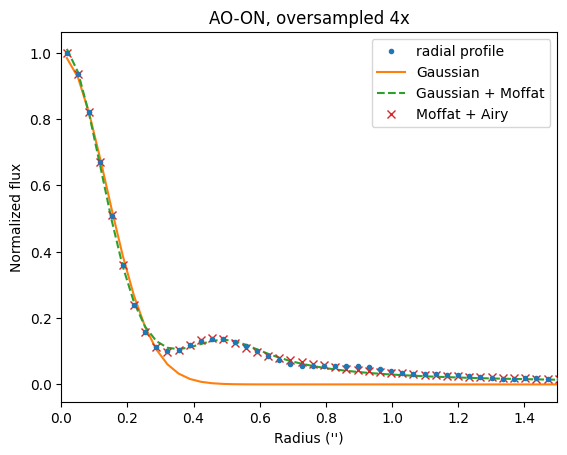

In [23]:
plt.title('AO-ON, oversampled 4x')

pixel_scale = 0.13522605304
radius_arc = rp.radius*pixel_scale/factor

plt.plot(radius_arc, rp.profile, 'o', markersize = 3, label='radial profile', zorder = 6)
plt.plot(radius_arc, rp.gaussian_profile, '-', label = 'Gaussian')
plt.plot(radius_arc, gauss_moffat(r), '--', label = 'Gaussian + Moffat')
plt.plot(radius_arc, moffat_airy(r), 'x', label = 'Moffat + Airy')

plt.xlabel("Radius ('')")
plt.ylabel('Normalized flux')
plt.legend()
plt.xlim([0,1.5])

(0.0, 1.5)

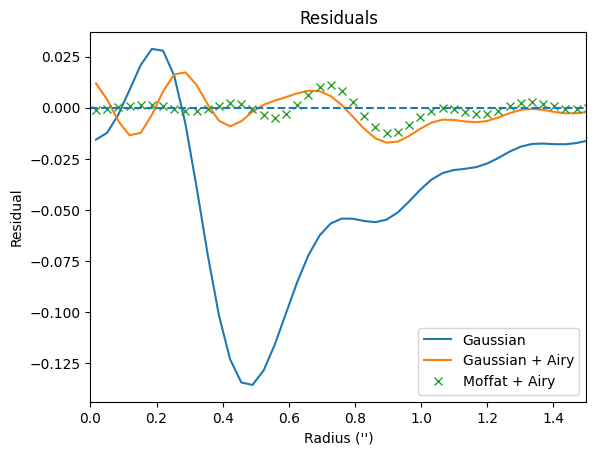

In [24]:
plt.title('Residuals')

plt.plot(radius_arc, rp.gaussian_profile - rp.profile, label = 'Gaussian')
plt.plot(radius_arc, gauss_moffat(r) - rp.profile, label = 'Gaussian + Airy')
plt.plot(radius_arc, moffat_airy(r) - rp.profile, 'x', label = 'Moffat + Airy')
plt.axhline(0, linestyle = '--')

plt.xlabel("Radius ('')")
plt.ylabel('Residual')
plt.legend()
plt.xlim([0,1.5])

## FWHM

In [25]:
# Empirical
radial_fwhm(r,rp.profile)*pixel_scale/factor

0.30817300140493276

In [26]:
# Gaussian
rp.gaussian_fwhm*pixel_scale/factor

0.319707682416298

In [27]:
# Gaussian + Moffat
radial_fwhm(r, gauss_moffat(r))*pixel_scale/factor

0.3002007305476645

In [28]:
# Airy + Moffat
radial_fwhm(r, gauss_moffat(r))*pixel_scale/factor

0.3002007305476645

## Curve of growth

/tmp/ipykernel_9954/2393584828.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{t * pixel_scale:.3f}' for t in ticks])


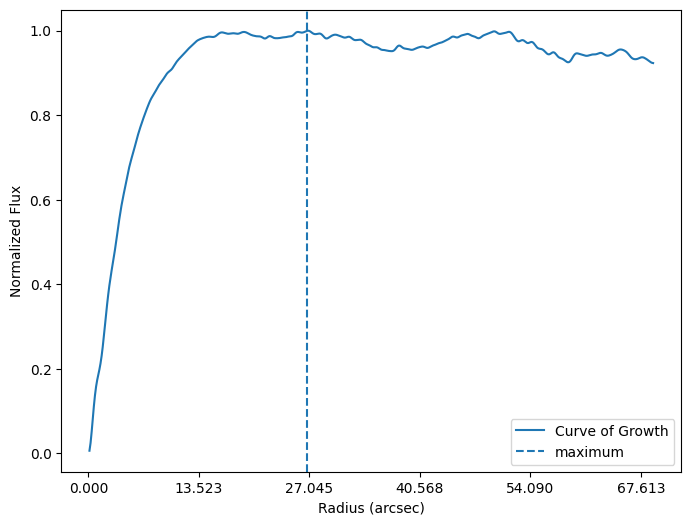

In [29]:
edge_radii = np.arange(1,np.shape(img_oversampled)[0]/2)
cog = CurveOfGrowth(img_oversampled, center, edge_radii, mask=None)

cog.normalize(method = 'max')

# plot the radial profile
fig, ax = plt.subplots(figsize=(8, 6))
cog.plot(ax=ax, label='Curve of Growth')
# cog.plot_error(ax=ax)
ax.axvline(np.argmax(cog.profile), ls='--', label='maximum')

ticks = ax.get_xticks()
ax.set_xticklabels([f'{t * pixel_scale:.3f}' for t in ticks])
ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Normalized Flux')

ax.legend()

# 2D fitting

## Gaussian

In [33]:
y, x = np.indices(img_oversampled.shape)
model = fit_gaussian2d(img_oversampled)
fitted_profile = model(x,y)

Goodness of fit: 20851452.402268942


(400.0, 624.0)

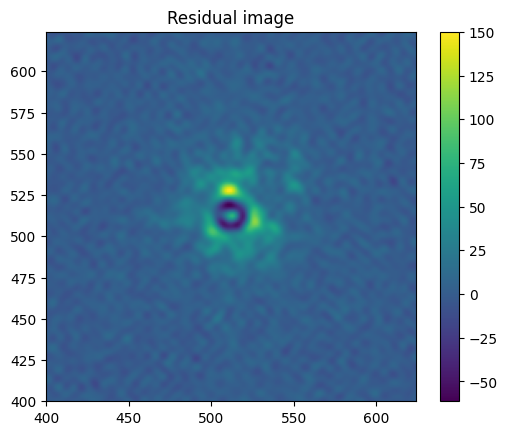

In [34]:
res = np.asarray(img_oversampled - fitted_profile)
print('Goodness of fit:', np.sum(res.flatten()**2))

plt.title('Residual image')

plt.imshow(res)
plt.colorbar()
plt.xlim([400,624])
plt.ylim([400,624])

In [35]:
# FWHM
fwhm_2d(fitted_profile)*pixel_scale/factor

0.35375669327129794

## Moffat

In [36]:
y, x = np.indices(img_oversampled.shape)
model = fit_moffat2d(img_oversampled)
fitted_profile = model(x,y)

Goodness of fit: 16797773.205989946


(400.0, 624.0)

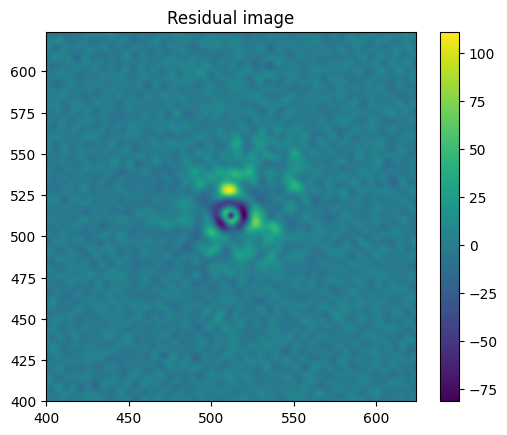

In [37]:
res = np.asarray(img_oversampled - fitted_profile)
print('Goodness of fit:', np.sum(res.flatten()**2))

plt.title('Residual image')

plt.imshow(res)
plt.colorbar()
plt.xlim([400,624])
plt.ylim([400,624])

In [38]:
# FWHM
fwhm_2d(fitted_profile)*pixel_scale/factor

0.24721799808036418

## Moffat + Airy

In [30]:
y, x = np.indices(img_oversampled.shape)
model = fit_moffat_airy_2d(img_oversampled)
fitted_profile = model(x,y)

Goodness of fit: 15737942.033301068


(400.0, 624.0)

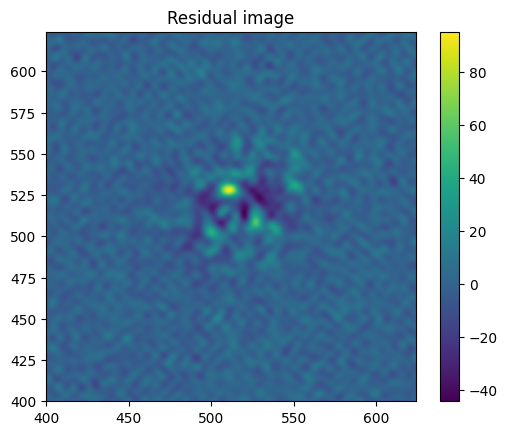

In [31]:
res = np.asarray(img_oversampled - fitted_profile)
print('Goodness of fit:', np.sum(res.flatten()**2))

plt.title('Residual image')

plt.imshow(res)
plt.colorbar()
plt.xlim([400,624])
plt.ylim([400,624])

In [32]:
# FWHM
fwhm_2d(fitted_profile)*pixel_scale/factor

0.30754744145710544

## Moffat + Gaussian

In [30]:
y, x = np.indices(img_oversampled.shape)
model = fit_moffat_gauss_2d(img_oversampled)
fitted_profile = model(x,y)

Goodness of fit: 15810101.942313557


(400.0, 624.0)

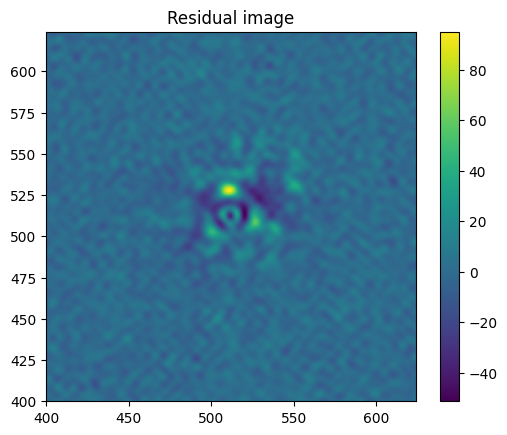

In [31]:
res = np.asarray(img_oversampled - fitted_profile)
print('Goodness of fit:', np.sum(res.flatten()**2))

plt.title('Residual image')

plt.imshow(res)
plt.colorbar()
plt.xlim([400,624])
plt.ylim([400,624])

In [32]:
# FWHM
fwhm_2d(fitted_profile)*pixel_scale/factor

0.2777111870985899

# Strehl ratio

## Calculating PSF

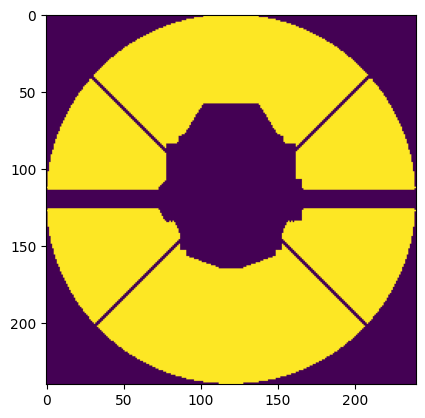

In [33]:
with fits.open('newshiftpupil.fits') as hdul:
    pup = hdul[0].data

plt.imshow(pup)

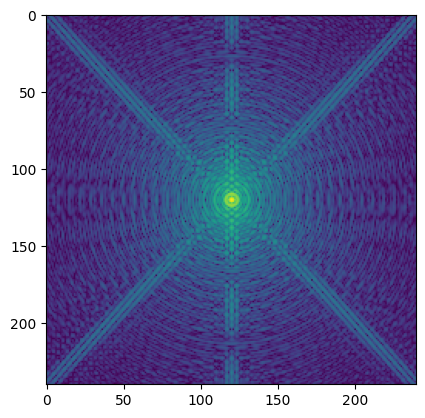

In [37]:
psf = pupil2psf(pup)
plt.imshow(np.log(psf+1e-7))

## Strehl ratio estimation

In [38]:
# aperture_radius_px = 148
aperture_radius_px = np.argmax(cog.profile)

psf = fft_oversample2d(psf, factor=4) # oversampling PSF

strehl = strehl_ratio(img_oversampled, psf, aperture_radius_px=aperture_radius_px)
print(strehl)

0.3067560722145134
